# Energy Consumption Prediction and Household Segmentation in Zurich
**Dataset**: HEAPO – Heat Pump Optimization Dataset.

**Predict monthly electricity consumption per household.**

Ich möchte den Energieverbrauch von Haushalten mit dem HEAPO-Datensatz vorhersagen (Zürich, 1.408 Haushalte, Zeitreihen + einige Haushalts- und Wetterdaten).
 
**Plan**:
 
Regression (Linear Regression, Random Forest)
 
Klassifikation (Verbrauchskategorien)
 
Clustering (K-Means, optional)

### Imports
**Note:** Before running the script, ensure that `data_path` is set to the correct location of the stored data.

In [1]:
# ----------------------
# IMPORT OTHER PACKAGES 
# ----------------------
import os 
import sys
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.dates as mdates
plt.rcParams["font.family"] = "sans-serif"

# ----------------------
# IMPORT HEAPO SCRIPTS
# ----------------------

# either run script heapo.py inside the src folder
# folder_path = os.path.dirname(os.getcwd())+'/src/'
# %run -i {folder_path + 'heapo.py'}

# or import heapo as a package - RECOMMENDED because Visual Studio Code then recognizes the package
folder_path = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0,'/Users/svetlana/Documents/CAS_ML/Project/heapo-main/src')
from heapo import *

# ---------------------------------------
# DEFINE PATH TO WHERE THE DATA IS STORED
# ---------------------------------------

# NOTE: if data is stored under /data/ within this repository --> set data_path = None 
data_path = '/Users/svetlana/Documents/CAS_ML/Project/heapo_data/'

# otherwise please provide the absolute path to the HEAPO dataset including the last slash
# data_path = '/Users/user/path/to/heapo_data/'

# ---------------------------------------
# CREATE HEAPO OBJECT
# ---------------------------------------

# create HEAPO object
heapo = HEAPO(data_path=data_path, use_local_time=False, suppress_warning=False)

## Problem Definition
**Task**: Predict monthly electricity consumption per household

**Input features**:

Weather (outdoor temperatures)

Living area (m2)

Number of residents

Heat pump type

Appliances:
EV (yes/no)
Dryer (yes/no)
Freezer (yes/no)etc

**Target**:
Monthly electricity consumption (kWh)

### Dataset Preparation

I need to aggregate the time-series into monthly values

In [2]:
df_meta_1 = heapo.get_meta_data_overview()
df_meta_1.count()

Household_ID                                   1408
Group                                          1408
Weather_ID                                     1408
Installation_HasPVSystem                        650
Protocols_Available                            1408
Protocols_HasMultipleVisits                    1408
Protocols_ReportIDs                             214
MetaData_Available                             1408
SmartMeterData_Available_15min                 1408
SmartMeterData_Available_Daily                 1408
SmartMeterData_Available_Monthly               1408
Survey_Building_Type                           1356
Survey_Building_LivingArea                     1339
Survey_Building_Residents                      1348
Survey_HeatPump_Installation_Type              1354
Survey_HeatDistribution_System_FloorHeating    1310
Survey_HeatDistribution_System_Radiator        1310
Survey_DHW_Production_ByHeatPump                851
Survey_DHW_Production_ByElectricWaterHeater     424
Survey_DHW_P

In [3]:
#df_meta_1.groupby('Survey_Building_Type').count()

In [4]:
df_meta_col = df_meta_1[
    ['Household_ID',
     'Survey_Building_Residents',
     'Survey_Building_LivingArea',
     'Survey_HeatPump_Installation_Type',
     'Survey_HeatDistribution_System_FloorHeating',
     'Survey_HeatDistribution_System_Radiator',
     'Survey_Installation_HasElectricVehicle',
     'Survey_Installation_HasFreezer',
     'Survey_Installation_HasDryer',
    ]
]
df_meta_col = df_meta_col.rename(columns=lambda x: x.replace('Survey_', ''))
df_meta_col.head()

,Household_ID,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer
0,1060,2.0,180.0,air-source,True,False,False,True,True
1,10266,2.0,240.0,air-source,False,True,True,True,True
2,11769,1.0,200.0,air-source,True,False,False,True,True
3,24611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,65651,2.0,180.0,air-source,False,True,False,True,False


In [5]:
def load_smart_meter_data_multiple_safe(household_ids):
    df_final = pd.DataFrame()
    for hid in household_ids:
        try:
            df = heapo.load_smart_meter_data(hid, resolution='monthly')
            if df is not None: 
                df_final = pd.concat([df_final, df], axis=0)
        except Exception as e:
            # print(f'{hid} error', e)
            pass
    df_final.drop_duplicates(inplace=True)
    df_final.reset_index(drop=True, inplace=True)
    if heapo.use_local_time: 
        df_final = heapo.__convert_UTC_to_local_time__(df_final, inplace=True)
    return df_final

houshold_ids = df_meta_col['Household_ID'].tolist()
#houshold_ids

In [6]:
df_meta = load_smart_meter_data_multiple_safe(houshold_ids)
df_meta

,Household_ID,Group,AffectsTimePoint,Timestamp,kWh_received_Total,kWh_received_HeatPump,kWh_received_Other,kWh_returned_Total,kvarh_received_capacitive_Total,kvarh_received_capacitive_HeatPump,kvarh_received_capacitive_Other,kvarh_received_inductive_Total,kvarh_received_inductive_HeatPump,kvarh_received_inductive_Other
0,1060,control,unknown,2022-05-31 23:59:59+00:00,653.90,NaN,NaN,NaN,17.81,NaN,NaN,8.25,NaN,NaN
1,1060,control,unknown,2022-06-30 23:59:59+00:00,486.23,NaN,NaN,NaN,9.39,NaN,NaN,12.55,NaN,NaN
2,1060,control,unknown,2022-07-31 23:59:59+00:00,494.41,NaN,NaN,NaN,12.63,NaN,NaN,3.92,NaN,NaN
3,1060,control,unknown,2022-08-31 23:59:59+00:00,476.31,NaN,NaN,NaN,13.04,NaN,NaN,3.30,NaN,NaN
4,1060,control,unknown,2022-09-30 23:59:59+00:00,550.09,NaN,NaN,NaN,115.77,NaN,NaN,0.51,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30205,9981041,treatment,after visit,2023-10-31 23:59:59+00:00,844.16,NaN,NaN,202.01,326.88,NaN,NaN,331.81,NaN,NaN
30206,9981041,treatment,after visit,2023-11-30 23:59:59+00:00,1236.10,NaN,NaN,53.27,266.34,NaN,NaN,658.23,NaN,NaN
30207,9981041,treatment,after visit,2023-12-31 23:59:59+00:00,1488.75,NaN,NaN,28.81,245.99,NaN,NaN,804.22,NaN,NaN
30208,9981041,treatment,after visit,2024-01-31 23:59:59+00:00,1653.95,NaN,NaN,42.73,223.19,NaN,NaN,887.61,NaN,NaN


In [7]:
df_meta['Household_ID'].unique().shape

(1264,)

In [8]:
# Export dataframe to Parquet file
df_meta.to_parquet("df_meta[.parquet", index=False)

In [9]:
def weather_per_month_for_household(household_id):
    weather = heapo.load_weather_data(household_id, resolution='daily')
    weather["Timestamp"] = pd.to_datetime(weather["Timestamp"])
    
    weather["month"] = weather["Timestamp"].dt.month
    
    monthly_stats = (
        weather.groupby("month")["Temperature_avg_daily"]
          .agg(["mean"])
    )
    monthly_stats = monthly_stats.rename(columns={
        "mean": "monthly_avg_temp",
    })
    monthly_stats['Household_ID'] = household_id
    monthly_stats.reset_index(inplace=True)
    return monthly_stats

def load_weather_data_safe(household_ids):
    df_final = pd.DataFrame()
    for hid in household_ids:
        try:
            df = weather_per_month_for_household(hid)
            if df is not None: 
                df_final = pd.concat([df_final, df], axis=0)
        except Exception as e:
            print(f'{hid} error', e)
            #pass
    df_final.drop_duplicates(inplace=True)
    df_final.reset_index(drop=True, inplace=True)
    return df_final


df_weather = load_weather_data_safe(df_meta['Household_ID'].unique())
df_weather

,month,monthly_avg_temp,Household_ID
0,1,1.752151,1060
1,2,4.613609,1060
2,3,6.396129,1060
3,4,9.535333,1060
4,5,13.336774,1060
...,...,...,...
15163,8,19.467097,9981041
15164,9,16.220000,9981041
15165,10,11.617419,9981041
15166,11,6.015333,9981041


In [10]:
df_weather

,month,monthly_avg_temp,Household_ID
0,1,1.752151,1060
1,2,4.613609,1060
2,3,6.396129,1060
3,4,9.535333,1060
4,5,13.336774,1060
...,...,...,...
15163,8,19.467097,9981041
15164,9,16.220000,9981041
15165,10,11.617419,9981041
15166,11,6.015333,9981041


In [12]:
df_meta_tmp = df_meta[['Household_ID', 'kWh_received_Total', 'Timestamp']].copy()

df_meta_tmp["Timestamp"] = pd.to_datetime(df_meta_tmp["Timestamp"])
df_meta_tmp["year"] = df_meta_tmp["Timestamp"].dt.year
df_meta_tmp["month"] = df_meta_tmp["Timestamp"].dt.month

df_meta_2 = (
    df_meta_tmp
    .groupby(['Household_ID', 'year', 'month'])['kWh_received_Total']
    .mean()
    .reset_index()
)

df_meta_2.head(20)

,Household_ID,year,month,kWh_received_Total
0,1060,2022,5,653.90
1,1060,2022,6,486.23
2,1060,2022,7,494.41
3,1060,2022,8,476.31
4,1060,2022,9,550.09
5,1060,2022,10,566.28
6,1060,2022,11,921.17
7,1060,2022,12,1279.48
8,1060,2023,1,1222.88
9,1060,2023,2,1013.62


In [13]:
df_meta_2 = df_meta_2.sort_values(by=["Household_ID", "year", "month"])
df_meta_2.head(20)

,Household_ID,year,month,kWh_received_Total
0,1060,2022,5,653.90
1,1060,2022,6,486.23
2,1060,2022,7,494.41
3,1060,2022,8,476.31
4,1060,2022,9,550.09
5,1060,2022,10,566.28
6,1060,2022,11,921.17
7,1060,2022,12,1279.48
8,1060,2023,1,1222.88
9,1060,2023,2,1013.62


In [14]:
df_meta_2["kWh_received_Total_hist"] = (
    df_meta_2.groupby("Household_ID")["kWh_received_Total"]
    .apply(lambda x: x.shift(1).expanding().mean())
    .reset_index(level=0, drop=True)
    .fillna(0)
    .round(2)
)
df_meta_2.head(10)

,Household_ID,year,month,kWh_received_Total,kWh_received_Total_hist
0,1060,2022,5,653.90,0.00
1,1060,2022,6,486.23,653.90
2,1060,2022,7,494.41,570.07
3,1060,2022,8,476.31,544.85
4,1060,2022,9,550.09,527.71
5,1060,2022,10,566.28,532.19
6,1060,2022,11,921.17,537.87
7,1060,2022,12,1279.48,592.63
8,1060,2023,1,1222.88,678.48
9,1060,2023,2,1013.62,738.97


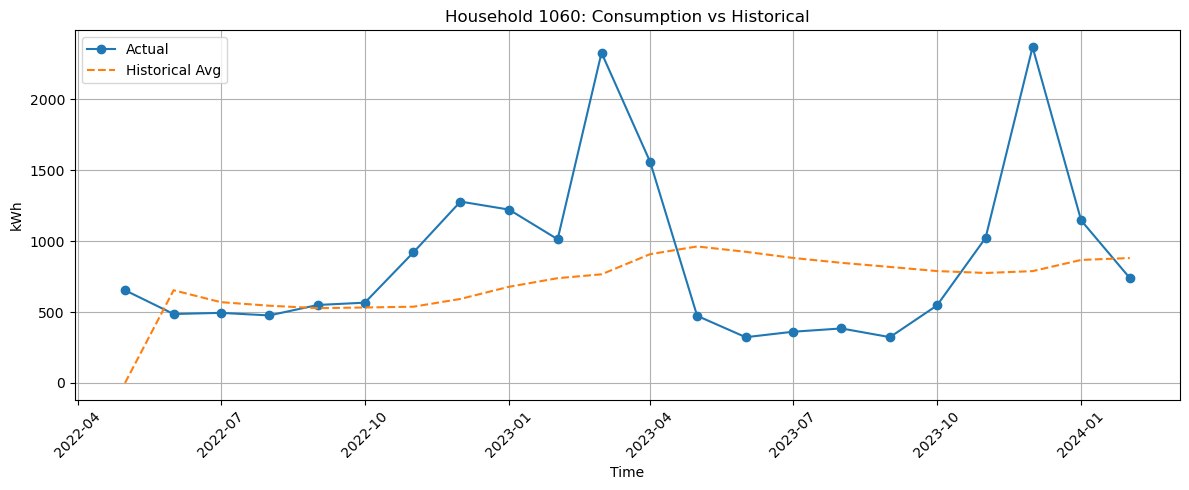

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data
df_1060 = df_meta_2[df_meta_2["Household_ID"] == 1060].copy()

df_1060["Timestamp"] = pd.to_datetime(
    dict(year=df_1060["year"], month=df_1060["month"], day=1)
)

df_1060 = df_1060.sort_values("Timestamp")

# Plot
plt.figure(figsize=(12, 5))

plt.plot(df_1060["Timestamp"], df_1060["kWh_received_Total"], 
         label="Actual", marker="o")

plt.plot(df_1060["Timestamp"], df_1060["kWh_received_Total_hist"], 
         label="Historical Avg", linestyle="--")

plt.xlabel("Time")
plt.ylabel("kWh")
plt.title("Household 1060: Consumption vs Historical")
plt.legend()
plt.grid()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# merge with Household Metadata
merge1_df = df_meta_2.merge(df_meta_col, on = 'Household_ID', how = 'left')
final_df = merge1_df.merge(df_weather, on = ['Household_ID', 'month'], how = 'left')
final_df.info()
final_df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30210 entries, 0 to 30209
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Household_ID                          30210 non-null  int64  
 1   year                                  30210 non-null  int32  
 2   month                                 30210 non-null  int32  
 3   kWh_received_Total                    29550 non-null  float64
 4   kWh_received_Total_hist               30210 non-null  float64
 5   Building_Residents                    29725 non-null  float64
 6   Building_LivingArea                   29475 non-null  float64
 7   HeatPump_Installation_Type            29816 non-null  object 
 8   HeatDistribution_System_FloorHeating  29281 non-null  object 
 9   HeatDistribution_System_Radiator      29281 non-null  object 
 10  Installation_HasElectricVehicle       26911 non-null  object 
 11  Installation_Ha

,Household_ID,year,month,kWh_received_Total,kWh_received_Total_hist,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer,monthly_avg_temp
0,1060,2022,5,653.90,0.00,2.0,180.0,air-source,True,False,False,True,True,13.336774
1,1060,2022,6,486.23,653.90,2.0,180.0,air-source,True,False,False,True,True,19.032667
2,1060,2022,7,494.41,570.07,2.0,180.0,air-source,True,False,False,True,True,20.214839
3,1060,2022,8,476.31,544.85,2.0,180.0,air-source,True,False,False,True,True,19.405806
4,1060,2022,9,550.09,527.71,2.0,180.0,air-source,True,False,False,True,True,15.881333
5,1060,2022,10,566.28,532.19,2.0,180.0,air-source,True,False,False,True,True,11.210968
6,1060,2022,11,921.17,537.87,2.0,180.0,air-source,True,False,False,True,True,5.577333
7,1060,2022,12,1279.48,592.63,2.0,180.0,air-source,True,False,False,True,True,3.025161
8,1060,2023,1,1222.88,678.48,2.0,180.0,air-source,True,False,False,True,True,1.752151
9,1060,2023,2,1013.62,738.97,2.0,180.0,air-source,True,False,False,True,True,4.613609


In [17]:
# missing values
final_df.isnull().sum()

Household_ID                               0
year                                       0
month                                      0
kWh_received_Total                       660
kWh_received_Total_hist                    0
Building_Residents                       485
Building_LivingArea                      735
HeatPump_Installation_Type               394
HeatDistribution_System_FloorHeating     929
HeatDistribution_System_Radiator         929
Installation_HasElectricVehicle         3299
Installation_HasFreezer                  507
Installation_HasDryer                    507
monthly_avg_temp                           0
dtype: int64

In [18]:
final_df['kWh_received_Total'].describe()

count    29550.000000
mean       837.491490
std        629.054889
min          0.030000
25%        416.240000
50%        699.575000
75%       1112.882500
max      14110.540000
Name: kWh_received_Total, dtype: float64

In [19]:
df = final_df.dropna(subset=['kWh_received_Total'])
df.isnull().sum()

Household_ID                               0
year                                       0
month                                      0
kWh_received_Total                         0
kWh_received_Total_hist                    0
Building_Residents                       453
Building_LivingArea                      703
HeatPump_Installation_Type               362
HeatDistribution_System_FloorHeating     895
HeatDistribution_System_Radiator         895
Installation_HasElectricVehicle         3161
Installation_HasFreezer                  475
Installation_HasDryer                    475
monthly_avg_temp                           0
dtype: int64

In [20]:
df

,Household_ID,year,month,kWh_received_Total,kWh_received_Total_hist,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer,monthly_avg_temp
0,1060,2022,5,653.90,0.00,2.0,180.0,air-source,True,False,False,True,True,13.336774
1,1060,2022,6,486.23,653.90,2.0,180.0,air-source,True,False,False,True,True,19.032667
2,1060,2022,7,494.41,570.07,2.0,180.0,air-source,True,False,False,True,True,20.214839
3,1060,2022,8,476.31,544.85,2.0,180.0,air-source,True,False,False,True,True,19.405806
4,1060,2022,9,550.09,527.71,2.0,180.0,air-source,True,False,False,True,True,15.881333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30205,9981041,2023,10,844.16,616.51,3.0,360.0,ground-source,True,False,NaN,True,False,11.617419
30206,9981041,2023,11,1236.10,644.96,3.0,360.0,ground-source,True,False,NaN,True,False,6.015333
30207,9981041,2023,12,1488.75,710.65,3.0,360.0,ground-source,True,False,NaN,True,False,3.167742
30208,9981041,2024,1,1653.95,788.46,3.0,360.0,ground-source,True,False,NaN,True,False,1.719892


In [21]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25550 entries, 0 to 30197
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Household_ID                          25550 non-null  int64  
 1   year                                  25550 non-null  int32  
 2   month                                 25550 non-null  int32  
 3   kWh_received_Total                    25550 non-null  float64
 4   kWh_received_Total_hist               25550 non-null  float64
 5   Building_Residents                    25550 non-null  float64
 6   Building_LivingArea                   25550 non-null  float64
 7   HeatPump_Installation_Type            25550 non-null  object 
 8   HeatDistribution_System_FloorHeating  25550 non-null  object 
 9   HeatDistribution_System_Radiator      25550 non-null  object 
 10  Installation_HasElectricVehicle       25550 non-null  object 
 11  Installation_HasFree

In [22]:
df.isna().sum()

Household_ID                            0
year                                    0
month                                   0
kWh_received_Total                      0
kWh_received_Total_hist                 0
Building_Residents                      0
Building_LivingArea                     0
HeatPump_Installation_Type              0
HeatDistribution_System_FloorHeating    0
HeatDistribution_System_Radiator        0
Installation_HasElectricVehicle         0
Installation_HasFreezer                 0
Installation_HasDryer                   0
monthly_avg_temp                        0
dtype: int64

In [23]:
df['HeatPump_Installation_Type'].value_counts()

HeatPump_Installation_Type
air-source       14380
ground-source    11170
Name: count, dtype: int64

In [24]:
df['HeatPump_Installation_Type'] = df['HeatPump_Installation_Type'].map({
    'air-source': 0,
    'ground-source': 1
})


/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_41922/1714013267.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['HeatPump_Installation_Type'] = df['HeatPump_Installation_Type'].map({


In [25]:
bool_cols = ['HeatDistribution_System_FloorHeating',
             'HeatDistribution_System_Radiator',
     'Installation_HasElectricVehicle',
     'Installation_HasFreezer',
     'Installation_HasDryer',
            ]
for col in bool_cols:
    df[col] = df[col].astype(float)


/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_41922/1710194026.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(float)
/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_41922/1710194026.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(float)
/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_41922/1710194026.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

In [26]:
df.drop(columns=['month','year'], inplace=True)

/var/folders/kh/qfjhgnwx6lj17jd04nqjhjl80000gp/T/ipykernel_41922/1607948373.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['month','year'], inplace=True)


In [27]:
#df = df[df['kWh_received_Total'] < 6000]
#Handle outliers
df = df[df['kWh_received_Total'] < df['kWh_received_Total'].quantile(0.99)]
df

,Household_ID,kWh_received_Total,kWh_received_Total_hist,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer,monthly_avg_temp
0,1060,653.90,0.00,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,13.336774
1,1060,486.23,653.90,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,19.032667
2,1060,494.41,570.07,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,20.214839
3,1060,476.31,544.85,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,19.405806
4,1060,550.09,527.71,2.0,180.0,0,1.0,0.0,0.0,1.0,1.0,15.881333
...,...,...,...,...,...,...,...,...,...,...,...,...
30193,9980121,349.12,340.75,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,11.210968
30194,9980121,635.13,341.19,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,5.577333
30195,9980121,1354.70,355.89,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,3.025161
30196,9980121,1560.22,403.45,2.0,165.0,0,1.0,0.0,0.0,0.0,1.0,1.752151


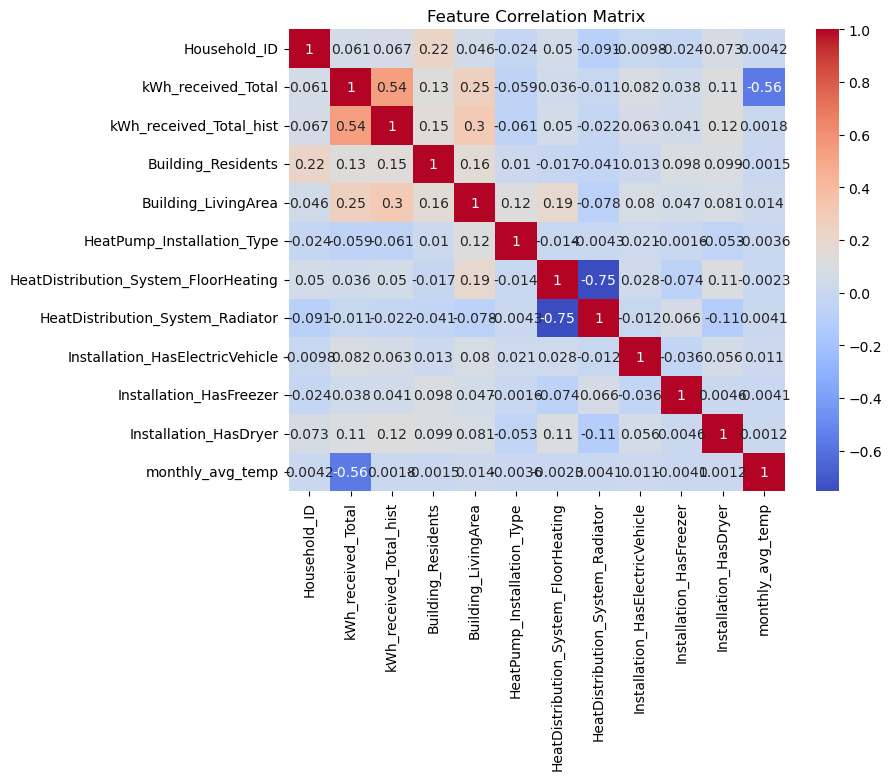

In [28]:
# correlation heatmap
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

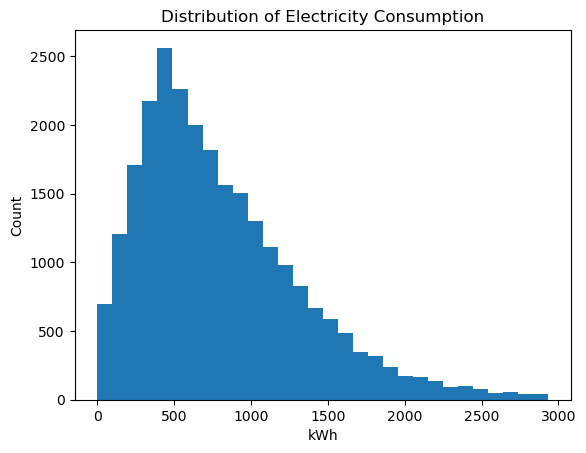

In [29]:
# How is electricity consumption distributed
plt.figure()
plt.hist(df['kWh_received_Total'], bins=30)
plt.xlabel('kWh')
plt.ylabel('Count')
plt.title('Distribution of Electricity Consumption')
plt.show()

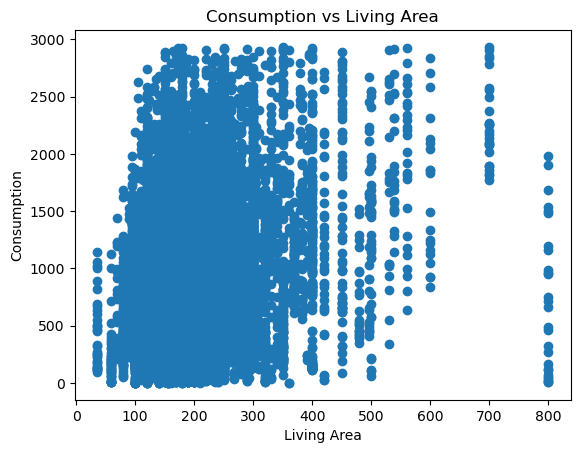

In [30]:
# Consumption vs Living Area
plt.figure()
plt.scatter(df['Building_LivingArea'], df['kWh_received_Total'])
plt.xlabel('Living Area')
plt.ylabel('Consumption')
plt.title('Consumption vs Living Area')
plt.show()

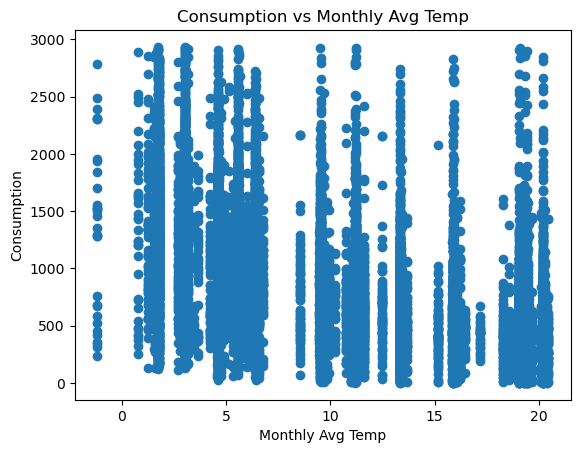

In [31]:
# Consumption vs Monthly_avg_temp
plt.figure()
plt.scatter(df['monthly_avg_temp'], df['kWh_received_Total'])
plt.xlabel('Monthly Avg Temp')
plt.ylabel('Consumption')
plt.title('Consumption vs Monthly Avg Temp')
plt.show()

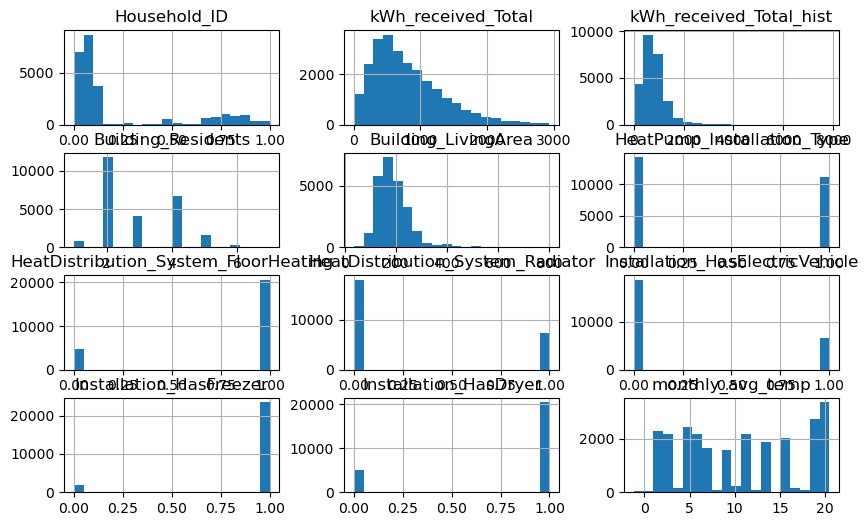

In [32]:
# Feature distributions
df.hist(figsize=(10, 6), bins=20)
plt.show()

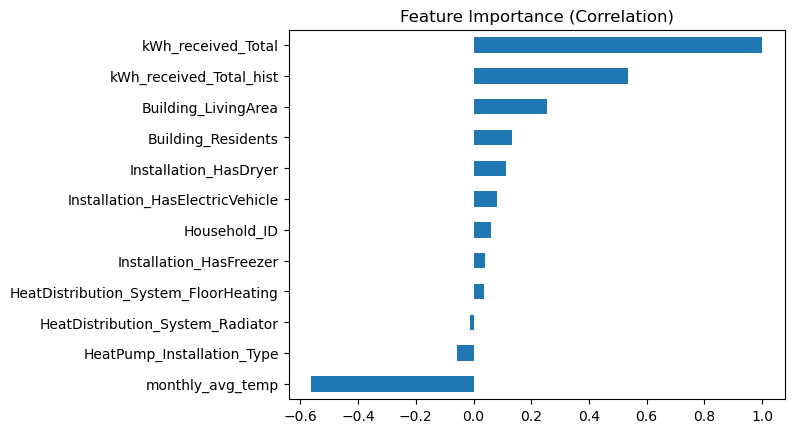

In [33]:
df.corr(numeric_only=True)['kWh_received_Total'].sort_values().plot(kind='barh')
plt.title('Feature Importance (Correlation)')
plt.show()


**Which features matter most**

**Monthly average temperature** → strongest predictor

**Living area** → second predictor

**Residents** → third predictor

**Heating system and the rest** → smaller effect


## Regression
### Linear Regression

In [44]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


=== Train Performance ===
MAE: 237.33626034398966
RMSE: 325.20271143341324
R²: 0.6198812732833205

=== Test Performance ===
MAE: 228.3669488896772
RMSE: 314.77202521162826
R²: 0.6381377935280639


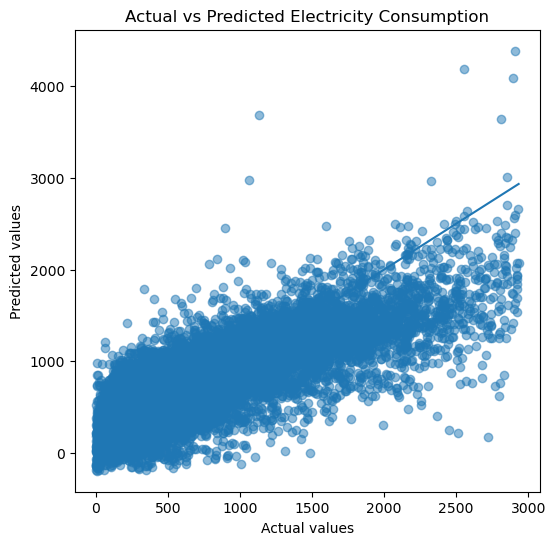

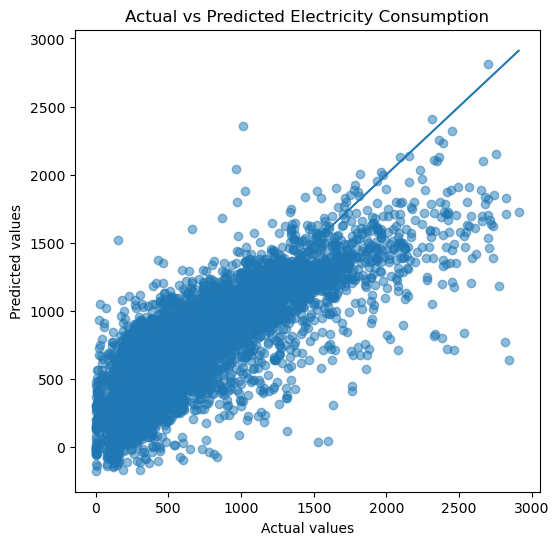

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define features (X) and target (y)
X = df.drop(columns = ['kWh_received_Total','Household_ID'])
y = df['kWh_received_Total']

# 1. Split using Household_ID (avoids leakage)
households = df["Household_ID"].unique()

train_households, test_households = train_test_split(
    households, test_size=0.2, random_state=42
)

train_df = df[df["Household_ID"].isin(train_households)]
test_df  = df[df["Household_ID"].isin(test_households)]


# 2. Define features (X) and target (y)
X_train = train_df.drop(columns=["kWh_received_Total", "Household_ID"])
y_train = train_df["kWh_received_Total"]

X_test = test_df.drop(columns=["kWh_received_Total", "Household_ID"])
y_test = test_df["kWh_received_Total"]


# 3. Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 4. Create and train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)


# 5. Metrics function
def compute_metrics(model, X, y):
    y_pred = model.predict(X)
    
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    
    return mae, rmse, r2


# 6. Plot function
def plot_predictions(model, X, y):
    y_pred = model.predict(X)
    
    plt.figure(figsize=(6,6))
    plt.scatter(y, y_pred, alpha=0.5)
    
    plt.xlabel("Actual values")
    plt.ylabel("Predicted values")
    plt.title("Actual vs Predicted Electricity Consumption")
    
    # Perfect prediction line
    plt.plot([y.min(), y.max()],
             [y.min(), y.max()])
    
    plt.show()


# 7. Evaluate model
print("=== Train Performance ===")
compute_metrics(model, X_train_scaled, y_train)

print("\n=== Test Performance ===")
mae_lr, rmse_lr, r2_lr = compute_metrics(model, X_test_scaled, y_test)


# 8. Plot results
plot_predictions(model, X_train_scaled, y_train)
plot_predictions(model, X_test_scaled, y_test)

### Random Forest

=== Random Forest Train Performance ===
MAE: 208.27084292664756
RMSE: 285.85843221960505
R²: 0.7062939010363928

=== Random Forest Test Performance ===
MAE: 202.45396131684794
RMSE: 278.97142866846013
R²: 0.715769667222756


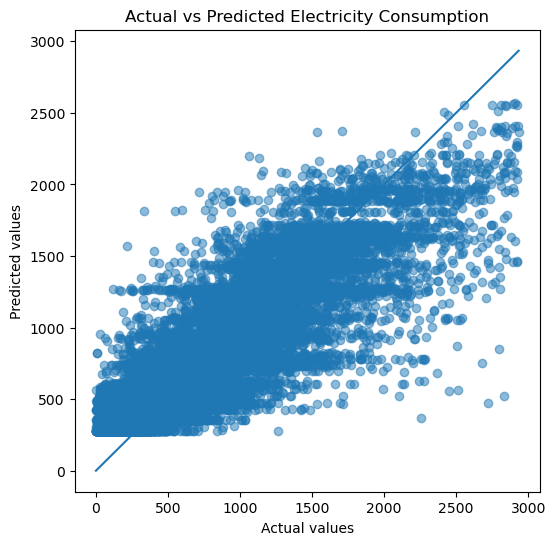

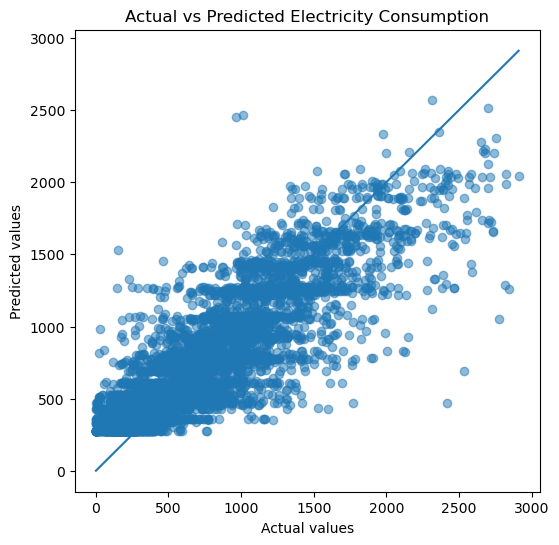

In [54]:
from sklearn.ensemble import RandomForestRegressor

# 1. Create model
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# 2. Train model 
rf.fit(X_train, y_train)


# 3. Evaluate model
print("=== Random Forest Train Performance ===")
compute_metrics(rf, X_train, y_train)

print("\n=== Random Forest Test Performance ===")
mae_rf, rmse_rf, r2_rf = compute_metrics(rf, X_test, y_test)


# 4. Plot results
plot_predictions(rf, X_train, y_train)
plot_predictions(rf, X_test, y_test)

In [55]:
print(r2_rf)

0.715769667222756


## Polynomial Regression Code


=== Polynomial Ridge Train Performance ===
MAE: 218.51963894451177
RMSE: 307.5755183558768
R²: 0.6599721580392043

=== Polynomial Ridge Test Performance ===
MAE: 209.93665408779862
RMSE: 296.9572921666199
R²: 0.677938390303084


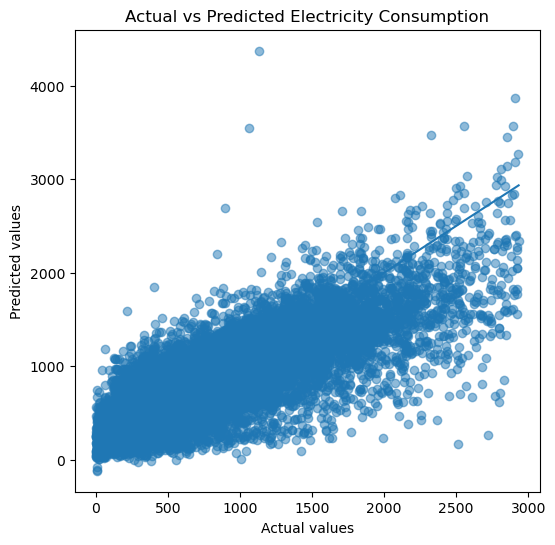

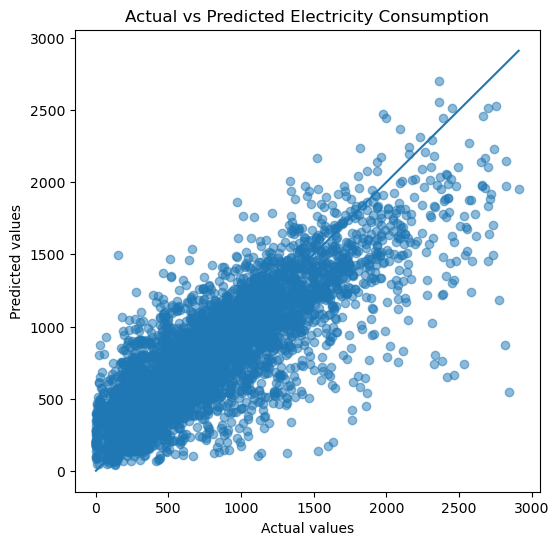

In [56]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

# 1. Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


# 2. Scale polynomial features
scaler = StandardScaler()

X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)


# 3. Train model (Ridge regression)
model_poly = Ridge(alpha=0.1)
model_poly.fit(X_train_poly, y_train)


# 4. Evaluate model
print("=== Polynomial Ridge Train Performance ===")
compute_metrics(model_poly, X_train_poly, y_train)

print("\n=== Polynomial Ridge Test Performance ===")
mae_pr, rmse_pr, r2_pr = compute_metrics(model_poly, X_test_poly, y_test)


# 5. Plot results
plot_predictions(model_poly, X_train_poly, y_train)
plot_predictions(model_poly, X_test_poly, y_test)

In [57]:
# Create comparison table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Polynomial Ridge"],
    "MAE": [mae_lr, mae_rf, mae_pr],
    "RMSE": [rmse_lr, rmse_rf, rmse_pr],
    "R²": [r2_lr, r2_rf, r2_pr]
})

# Better rounding (keep meaning!)
results = results.round({
    "MAE": 3,
    "RMSE": 3,
    "R²": 3
})

print(results)

               Model      MAE     RMSE     R²
0  Linear Regression  228.367  314.772  0.638
1      Random Forest  202.454  278.971  0.716
2   Polynomial Ridge  209.937  296.957  0.678


**Result shows:**

simple linear model ≈ complex model

→ data has limited predictive signal

**The results suggest that household characteristics alone are insufficient to fully explain electricity consumption, and additional dynamic features such as temporal patterns would be required for higher accuracy.**

## Classification with Logistic Regression

We convert consumption into:

**low** (0)
**medium** (1)
**high** (2)

In [58]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# splits data into 3 equal groups
y_class = pd.qcut(y, q=3, labels=[0, 1, 2])
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))

Logistic Regression Results:
Accuracy: 0.7001383672662581
Precision: 0.6958677376545381
Recall: 0.7001383672662581


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


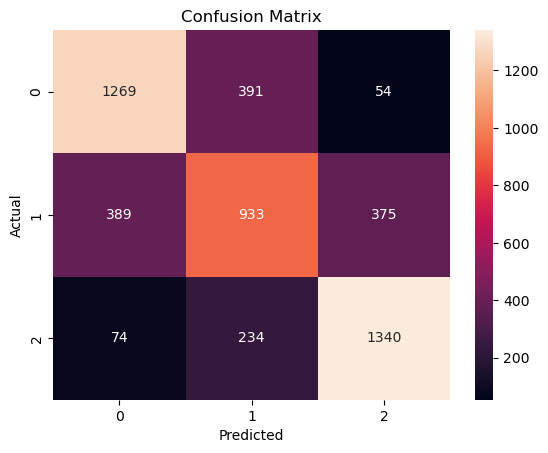

In [59]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1269  391   54]
 [ 389  933  375]
 [  74  234 1340]]


The model performs well on low and high consumption households, but struggles with the medium class. This indicates that energy consumption behaves as a continuous variable rather than discrete categories, making class separation challenging